# Assignment 1: Data analysis, visualization and comparison
Nahia Urra López de Heredia (nahia.urra01@estudiant.upf.edu)

Last update: 26 March, 2026

- Exercise 1
- Exercise 2
- Exercise 3
- Session Info

# Exercise 1

Download and load Supplementary Table 1 (“Additional Demographical and Baseline Characteristics of COVID-19 Patients and Control Groups”) from the supplementary materials of the publication.

## Exercise 1.1 

Reproduce Table 1 from the manuscript using the supplementary data. Match the reported summary statistics as closely as possible.

Then, briefly discuss any discrepancies between your results and the published table, and provide possible explanations.

In [ ]:
knitr::opts_chunk$set(echo = TRUE)

setwd("/home/nahia/uni/2nd/dmi/assignment-1-nahiauuu/data")

## Load the libraries we're going to use
library(readxl)
library(tidyverse)
library(lubridate)
library(gtsummary)
library(gt)
library(dplyr)
library(ggplot2)
library(tidyr)
library(knitr)
library(kableExtra)


# Read the second sheet of the excel file -> the table with the data
data <- read_excel("1-s2.0-S0092867420306279-mmc1.xlsx", sheet = "Clinical_information")



# Cleaning and Re-coding
data_table_sup1 <- data %>%
  mutate(
    # Main groups
    covid_status = case_when(
      `Group d` == 0 ~ "Healthy Control",
      `Group d` == 1 ~ "Non-COVID-19",
      `Group d` == 2 ~ "Non-severe",
      `Group d`== 3 ~ "Severe"
    ),


    # Cleaning ----> As we detected that 'NAs' in 'date of progression to severe state' are indicated as '/', we are going to replace the '/'s with 'NA's:
    
    severe_date_raw = na_if(`Date of progression to severe state`, "/"),
    severe_date = as.Date(as.numeric(severe_date_raw), origin = "1899-12-30"),

    # Sex
    Sex = factor(`Sex g`,
                 levels = c(1, 0),
                 labels = c("Male", "Female")),

    # Numeric variables
    Age = `Age (year)`,
    # The BMI variable is as a 'chr' so, we make it a numeric variable
    BMI = as.numeric(`BMI h`),

    # Time from onset to admission in days
    # Compute the difference between dates
    onset_to_admission = as.numeric(difftime(`Admission date`, `Onset date f`, units = "days")),

    # Time from admission to severe in days (only for severe patients)
    admission_to_severe = case_when(
      covid_status != "Severe" ~ NA_real_,
      is.na(severe_date) ~ NA_real_,
      severe_date < `Admission date` ~ NA_real_,
      TRUE ~ as.numeric(difftime(severe_date, `Admission date`, units = "days"))
    )
  )



### Table 1: Main groups
table_main <- data_table_sup1 %>%
  filter(covid_status %in% c("Healthy Control", "Non-COVID-19")) %>%
  select(covid_status, Sex, Age, BMI) %>%
  tbl_summary(
    by = covid_status,
    type = all_continuous() ~ "continuous2",
    statistic = list(
      all_continuous() ~ c(
        "{mean} ± {sd}",
        "{median} ({p25}-{p75})",
        "{min}-{max}"
      ),
      all_categorical() ~ "{n} ({p}%)"
    ),
    digits = all_continuous() ~ 1,
    missing = "no"
  )

### Table COVID-19: severity
table_covid_nonsev <- data_table_sup1 %>%
  filter(covid_status %in% c("Non-severe")) %>%
  select(covid_status, Sex, Age, BMI, onset_to_admission
  ) %>%
  tbl_summary(
    by = covid_status,
    type = all_continuous() ~ "continuous2",
    statistic = list(
      all_continuous() ~ c(
        "{mean} ± {sd}",
        "{median} ({p25}-{p75})",
        "{min}-{max}"
      ),
      all_categorical() ~ "{n} ({p}%)"
    ),
    digits = all_continuous() ~ 1,
    missing = "no"
  )

table_covid_sev <- data_table_sup1 %>%
  filter(covid_status %in% c("Severe")) %>%
  select(covid_status, Sex, Age, BMI, onset_to_admission, admission_to_severe
  ) %>%
  tbl_summary(
    by = covid_status,
    type = list(
        admission_to_severe ~ "continuous2",
        all_continuous() ~ "continuous2"
      ),   
    statistic = list(
      all_continuous() ~ c(
        "{mean} ± {sd}",
        "{median} ({p25}-{p75})",
        "{min}-{max}"
      ),
      all_categorical() ~ "{n} ({p}%)"
    ),
    digits = all_continuous() ~ 1,
    missing = "no"
  )




### Table Total COVID-19
table_covid_total <- data_table_sup1 %>%
  filter(covid_status %in% c("Non-severe", "Severe")) %>%
  select(Sex, Age, BMI, onset_to_admission) %>%
  tbl_summary(
    type = all_continuous() ~ "continuous2",
    statistic = list(
      all_continuous() ~ c(
        "{mean} ± {sd}",
        "{median} ({p25}-{p75})",
        "{min}-{max}"
      ),
      all_categorical() ~ "{n} ({p}%)"
    ),
    digits = all_continuous() ~ 1,
    missing = "no"
  )




### Merging the previous tables

table1 <- tbl_merge(
  tbls = list(table_main, table_covid_total, table_covid_nonsev, table_covid_sev),
  tab_spanner = c(
    NA,
    "COVID-19",
    "COVID-19",
    "COVID-19"
  )
)



### The final formatting:

table1_gt <- table1 %>%
  modify_header(label ~ "**Variables**", stat_0_2 ~ "**Total**<br>N = {N}") %>%
  modify_table_body(
    ~ .x %>%
      mutate(
        label = case_when(
          row_type == "label" & label == "Sex" ~ "Sex - no. (%)",
          row_type == "label" & label == "Age" ~ "Age - year",
          row_type == "label" & label == "BMI" ~ "BMI, kg/m²",
          row_type == "label" & label == "onset_to_admission" ~
            "Time from Onset to Admission, Days",
          row_type == "label" & label == "admission_to_severe" ~
            "Time from Admission to Severe, Days",

          label == "Median (Q1-Q3)" ~ "Median (IQR)",
          label == "Min-Max" ~ "Range",
          TRUE ~ label
        )
      )
  ) %>%
  modify_footnote(
    all_stat_cols() ~ NA
  ) %>%
  as_gt() %>%
  tab_options(
    table.font.size = px(8)
  ) %>%
  tab_header(
    title = "Table 1. Demographics and Baseline Characteristics of COVID-19 Patients"
  ) %>%
  opt_all_caps() %>%
  tab_style(
    style = cell_fill(color = "white"),
    locations = cells_body(
      rows = row_type == "label"
    )
  ) %>%
  tab_style(
    style = cell_fill(color = "#F2F2F2"),
    locations = cells_body(
      rows = row_type %in% c("level", "stat")
    )
  )

# Output table: "table1_gt"



#---> Were going to save it locally as an HTML file, so it can be seen as a similar table as the one in the original article, with the right formatting
gtsave(table1_gt, "results/Table1_reproduced.html")




Adjuntando el paquete: ‘kableExtra’


The following object is masked from ‘package:dplyr’:

    group_rows


New names:
• `Test date` -> `Test date...18`
• `Test date` -> `Test date...23`
Warning message:
“There was 1 warning in `mutate()`.
ℹ In argument: `BMI = as.numeric(`BMI h`)`.
Caused by warning:
! NAs introducidos por coerción”
The number rows in the tables to be merged do not match, which may result in
rows appearing out of order.
ℹ See `tbl_merge()` (`?gtsummary::tbl_merge()`) help file for details. Use
  `quiet=TRUE` to silence message.


## Exercise 1.2

Perform an exploratory data analysis (EDA) of the dataset. At a minimum, include:

- Descriptive statistics for key variables  
- Appropriate visualizations (e.g. distributions, group comparisons)  
- A brief written summary of notable patterns, anomalies, or data quality issues  

### Cleaning

In [12]:
# Distinguish attributes
# We executed str(data) in order to know the structure of the data and the type of each attribute
str(data)

# CLEANING
data_cleaned <- data

# New names for better manipulation of the data
# Previously, very long and complex names (with spaces, units, etc)
new_names <- c("patient_id","proteomics","ms_id","msrep_id","group","covid_cohort","metabolomics","metabolomics_id","onset_date","admission_date","severe_date","sampling_date_metabolomics","sampling_date_proteomics","discharge_date","sex","age","bmi","test_date_1","wbc_count_×109/L","lymphocyte_count_×109/L","monocyte_count_×109/L","platelet_count_×109/L","test_date_2","crp_mg/L","alt_U/L","ast_U/L","ggt_U/L","tbil_μmol/L","dbil_μmol/L","creatinine_μmol/L","glucose_mmol/L")
names(data_cleaned) <- new_names

# Cleaning incorrect formatting variables
# We detected that 'NAs' in 'date of progression to severe state' are indicated as '/'
# Replace '/' with NA in several variable with this incorrect format
data_cleaned$severe_date <- na_if(data_cleaned$severe_date, "/")
data_cleaned$ms_id <- na_if(data_cleaned$ms_id, "/")
data_cleaned$msrep_id <- na_if(data_cleaned$msrep_id, "/")
data_cleaned$covid_cohort <- na_if(data_cleaned$covid_cohort, "/")
data_cleaned$sampling_date_proteomics <- na_if(data_cleaned$sampling_date_proteomics, "/")
data_cleaned$bmi <- na_if(data_cleaned$bmi, "/")
data_cleaned$`crp_mg/L` <- na_if(data_cleaned$`crp_mg/L`, "/")
data_cleaned$metabolomics_id <- na_if(data_cleaned$metabolomics_id, "/")

# Reformat correctly the date of severe state
data_cleaned$severe_date <- as.Date(as.numeric(data_cleaned$severe_date), origin = "1899-12-30")

# Convert BMI and CRP to numeric
data_cleaned$bmi <- as.numeric(data_cleaned$bmi)
data_cleaned$`crp_mg/L` <- as.numeric(data_cleaned$`crp_mg/L`)

# Add variable: 
# time from onset to admission -> compute the difference between dates
data_cleaned$onset_to_admission = as.numeric(difftime(data_cleaned$admission_date, data_cleaned$onset_date, units = "days"))

# time from admission to severe
data_cleaned$admission_to_severe = case_when(
      is.na(data_cleaned$severe_date) ~ NA_real_,
      data_cleaned$severe_date < data_cleaned$admission_date ~ NA_real_,
      TRUE ~ as.numeric(difftime(data_cleaned$severe_date, data_cleaned$admission_date, units = "days"))
    )

# RENAME the categorical variables
# Rename the value of the 'group' variable to uncode them to make them more understandable
data_cleaned$group <- case_when(
  data_cleaned$group == 0 ~ "Healthy Control",
  data_cleaned$group == 1 ~ "Non-COVID-19",
  data_cleaned$group == 2 ~ "Non-severe",
  data_cleaned$group == 3 ~ "Severe"
)
# Rename the value of the 'sex' variable to make it more understandable
data_cleaned$sex <- case_when(
  data_cleaned$sex == 1 ~ "Male",
  data_cleaned$sex == 0 ~ "Female"
)

tibble [118 × 31] (S3: tbl_df/tbl/data.frame)
 $ Patient ID a                       : chr [1:118] "XG1" "XG2" "XG3" "XG4" ...
 $ Proteomics                         : chr [1:118] "Yes" "Yes" "Yes" "Yes" ...
 $ MS ID b                            : chr [1:118] "F1_126" "F1_127N" "F1_127C" "F2_126" ...
 $ MSRep ID c                         : chr [1:118] "F1_133N" "/" "/" "/" ...
 $ Group d                            : num [1:118] 2 2 2 2 2 2 2 2 2 2 ...
 $ COVID-19 patients corhort          : chr [1:118] "Training (C1)" "Training (C1)" "Training (C1)" "Training (C1)" ...
 $ Metabolomics analysis              : chr [1:118] "Yes" "Yes" "Yes" "Yes" ...
 $ Metabolomics ID e                  : chr [1:118] "PT1" "PT2" "PT3" "PT4" ...
 $ Onset date f                       : POSIXct[1:118], format: "2020-01-24" "2020-01-31" ...
 $ Admission date                     : POSIXct[1:118], format: "2020-01-25" "2020-02-02" ...
 $ Date of progression to severe state: chr [1:118] "/" "/" "/" "/" ...
 $ Sam

Warning message:
“NAs introducidos por coerción”


### Checking data balancing 

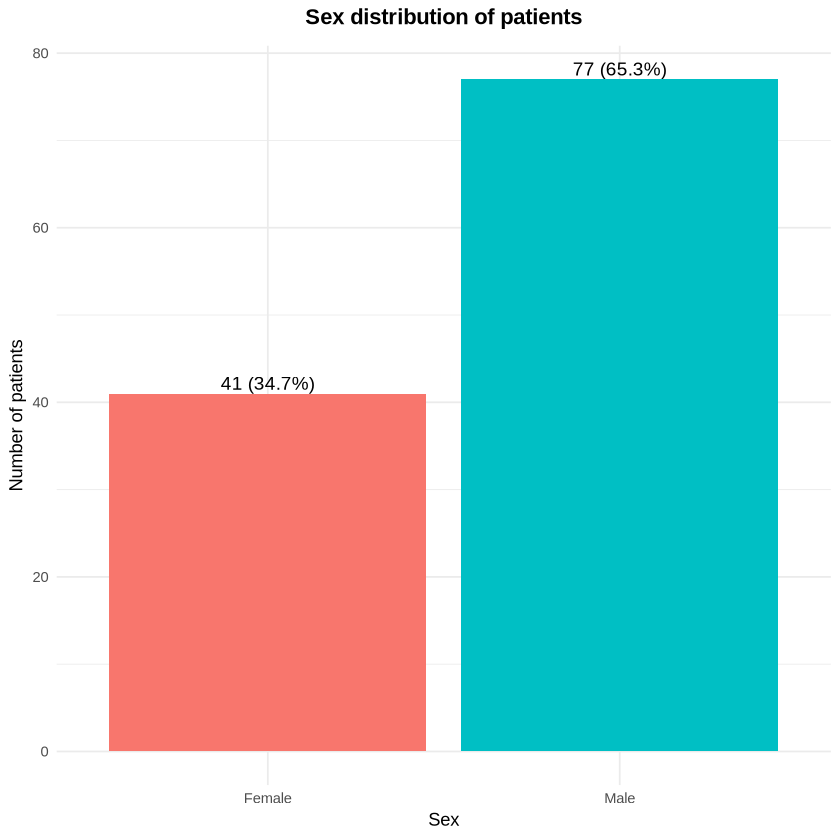

In [13]:
# Distribution of sex
sex_dist <- data_cleaned %>%
  filter(!is.na(sex)) %>%
  count(sex) %>%
  mutate(percentage = n / sum(n) * 100)

# Bar plot
ggplot(sex_dist, aes(x = sex, y = n, fill = sex)) +
  geom_bar(stat = "identity") +
  geom_text(aes(label = paste0(n, " (", round(percentage, 1), "%)")),
            vjust = -0.3, size = 4) +
  labs(
    title = "Sex distribution of patients",
    x = "Sex",
    y = "Number of patients"
  ) +
  theme_minimal() +
  theme(legend.position = "none",
        plot.title = element_text(hjust = 0.5,face = "bold",margin = margin(b = 10)))

As we can see in the bar plot above, in terms of sex, the dataset is unbalanced, with 65% of the patients being male, whereas we would expect an approximately equal distribution of 50% for each sex.

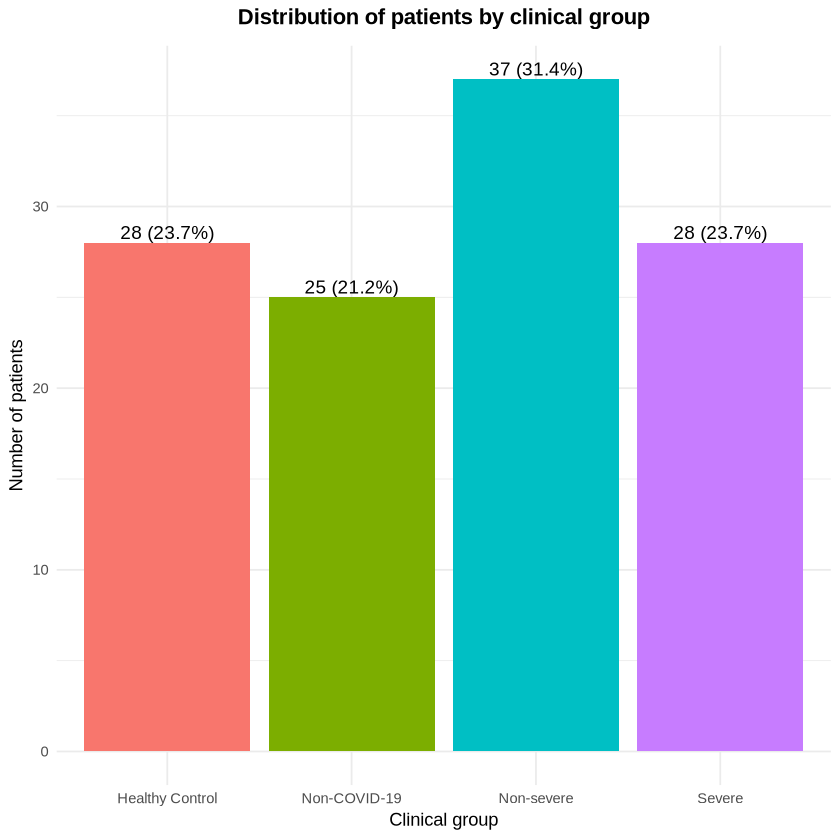

In [14]:
# Distribution of clinical groups
group_dist <- data_cleaned %>%
  filter(!is.na(group)) %>%
  count(group) %>%
  mutate(
    percentage = n / sum(n) * 100
  )

# Bar plot
ggplot(group_dist, aes(x = group, y = n, fill = group)) +
  geom_bar(stat = "identity") +
  geom_text(aes(label = paste0(n, " (", round(percentage, 1), "%)")),
            vjust = -0.3, size = 4) +
  labs(
    title = "Distribution of patients by clinical group",
    x = "Clinical group",
    y = "Number of patients"
  ) +
  theme_minimal() +
  theme(legend.position = "none",
        plot.title = element_text(hjust = 0.5,face = "bold",margin = margin(b = 10)))


In contrast, regarding the 'group' variable, which reflects patient severity, the categories are generally well balanced, except for the 'non-severe' group, which accounts for 31% of the patients, while the other groups represent between 21% and 23% each.

Despite this results, we think that there is no need to do balancing.


### Detection of Missing data (NA)

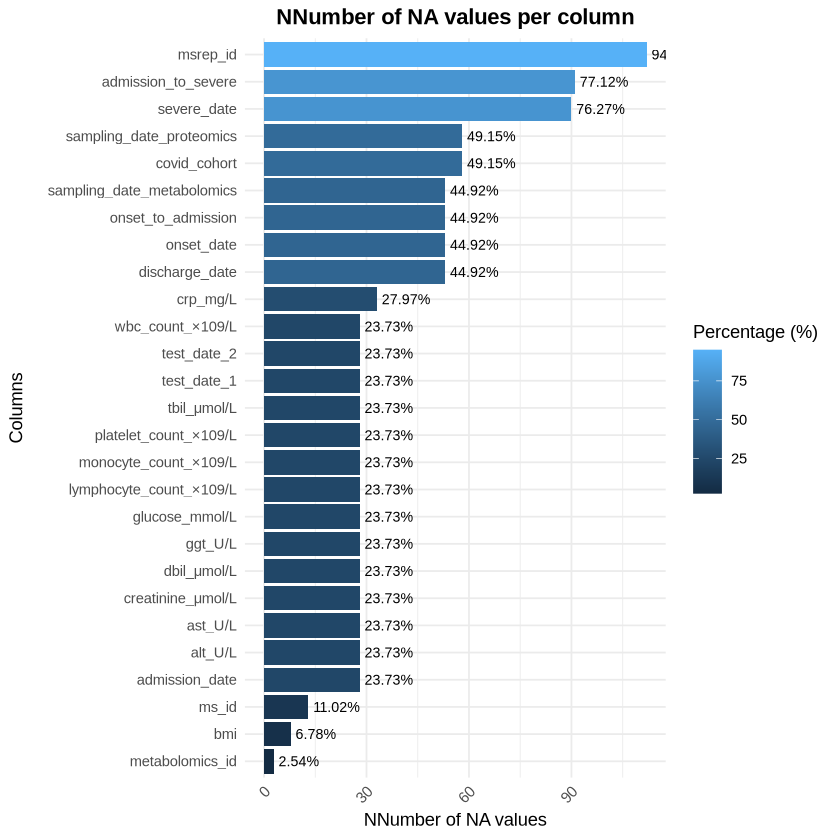

In [15]:
# First, check for missing values (NA) in the dataset
# Compute NA count and percentage per column
na_summary <- data.frame(column = names(data_cleaned), na_count = colSums(is.na(data_cleaned)), na_percentage = colSums(is.na(data_cleaned)) / nrow(data_cleaned) * 100)

# Show only columns with NA values sorted by na_count
na_summary <- na_summary %>% filter(na_count > 0) %>% arrange(na_count)

# Bar plot of NA counts per column
ggplot(na_summary, aes(x = reorder(column, na_count), y = na_count, fill = na_percentage)) +
  geom_bar(stat = "identity") +
  geom_text(aes(label = paste0(round(na_percentage, 2), "%")), 
            hjust = -0.1, size = 3) +  # Adjust position of text
  coord_flip() +  # To make the bars horizontal
  labs(
    title = "NNumber of NA values per column",
    x = "Columns",
    y = "NNumber of NA values",
    fill = "Percentage (%)"
  ) +
  theme_minimal() +
  theme(
    plot.title = element_text(hjust = 0.5, face = "bold"),
    axis.text.x = element_text(angle = 45, hjust = 1)
  )

As shown in the plot, the technical replicate sample ID is missing in approximately 94% of the patients, which likely indicates that technical replicates were not performed for most of the individuals. However, these IDs are not relevant for our analysis, as they do not provide information related to disease severity (the main variable of interest) and therefore they will not be considered.

The variables with the second highest proportion of missing values are the date of progression to severe disease and, consequently, the number of days between admission and progression to severe status. Since these variables are only applicable to patients who developed severe disease the % of missing data makes sense. We will exclude the corresponding data variables hile retaining the derived numerical variables that represent the time intervals between disease states. The same will be applied to the onset date and the time from onset to admission.

It is important to note that although several variables present missing values for up to 76% of the patients, this is expected, as these missing values correspond to patients who never progressed to a severe state. Therefore, no imputation is performed for these variables. Additionally, one extra missing value is observed due to a data entry error in which the recorded date of progression to severe disease precedes the admission date.

The next group of variables with a high proportion of missing values includes those collected exclusively for COVID-19 patients (both non-severe and severe), resulting in approximately 44–49% missings. These variables mainly correspond to dates, and as we previously commented there are not directly relevant for the current analysis, so we retain only the derived time intervals, such as the number of days between onset and admission.

Furthermore, biological measurements were obtained only for COVID-19 patients, therefore, these variables are missing for approximately 24% of the dataset, corresponding to healthy control individuals so, no imputation is applied. Similarly, the proteomics and metabolomics sample IDs are missing for 11% and 2.5% of patients, respectively and since these identifiers are not informative for severity analysis, they are not imputed.

Finally, body mass index (BMI) is missing for approximately 7% of patients. As there is no clear biological or technical explanation for this missings, it is likely due to incomplete data recording. Therefore, BMI values will be imputed within groups to preserve potential group-specific patterns. The same will be applied to crp which has 5 random NAs. 


### Imputation of the NAs of BMI

In [16]:
# At data_cleaned we will maintain only the variables that we will use for the analysis
# Remove the following columns
data_cleaned <- data_cleaned %>%
  select(-c(proteomics, ms_id, msrep_id, covid_cohort, metabolomics, metabolomics_id, onset_date, admission_date, severe_date, sampling_date_metabolomics, sampling_date_proteomics, discharge_date, test_date_1, test_date_2))

# IMPUTATION of NAs in BMI and CRP
# We want to impute the missing values but by groups
# So, for instance, to impute the missing values of patients of the group 0 only BMIs of the patients with the same sex and from the group 0 will be taken into account.

# Check that the number of NAs in BMI and CRP
sum(is.na(data_cleaned$bmi))
sum(is.na(data_cleaned$`crp_mg/L`))

data_cleaned <- data_cleaned %>%
  group_by(group, sex) %>%
  mutate(
    bmi = ifelse(
      is.na(bmi),
      mean(bmi, na.rm = TRUE),
      bmi
    ),
    `crp_mg/L` = ifelse(
      is.na(`crp_mg/L`) & group %in% c("Non-COVID-19", "Non-severe", "Severe"),
      median(`crp_mg/L`, na.rm = TRUE),
      `crp_mg/L`
    )
  ) %>%
  ungroup()

# Check that there are no more NAs in BMI
sum(is.na(data_cleaned$bmi))
sum(is.na(data_cleaned$`crp_mg/L`))


[1] 8

[1] 33

[1] 0

[1] 28

### Descriptive statistics for the key variables

As we have cleaned the data, now we can perform the EDA with the remaining variables that are the key ones; first, we will separate categorical and numerical variables for better analysis

In [17]:
###---------> Only CATEGORICAL variables
# We don't select the Patient ID so, as categorical we only have 'sex' and 'group'
categorical_cols <- c("sex", "group")



###---------> Only NUMERICAL variables
numeric_cols <- c("age", "bmi", "wbc_count_×109/L", "lymphocyte_count_×109/L", 
                   "monocyte_count_×109/L", "platelet_count_×109/L",
                   "crp_mg/L", "alt_U/L", "ast_U/L", "ggt_U/L", "tbil_μmol/L", 
                  "dbil_μmol/L", "creatinine_μmol/L", "glucose_mmol/L",
                  "onset_to_admission", "admission_to_severe")

data_numeric <- data_cleaned %>%
  select(all_of(numeric_cols))

data_categorical <- data_cleaned %>%
  select(all_of(categorical_cols))

### Univariate Analysis:


<table class="table table-striped table-hover table-condensed" style="width: auto !important; margin-left: auto; margin-right: auto;">
<caption>Descriptive statistics of numeric variables</caption>
 <thead>
  <tr>
   <th style="text-align:left;"> Variable </th>
   <th style="text-align:right;"> n </th>
   <th style="text-align:right;"> Mean </th>
   <th style="text-align:right;"> SD </th>
   <th style="text-align:right;"> Median </th>
   <th style="text-align:right;"> Min </th>
   <th style="text-align:right;"> Max </th>
  </tr>
 </thead>
<tbody>
  <tr>
   <td style="text-align:left;"> age </td>
   <td style="text-align:right;"> 118 </td>
   <td style="text-align:right;"> 47.42 </td>
   <td style="text-align:right;"> 12.82 </td>
   <td style="text-align:right;"> 47.00 </td>
   <td style="text-align:right;"> 18.00 </td>
   <td style="text-align:right;"> 77.00 </td>
  </tr>
  <tr>
   <td style="text-align:left;"> bmi </td>
   <td style="text-align:right;"> 118 </td>
   <td style="text-al

Category,Frequency,Percentage
<chr>,<dbl>,<dbl>
Female,41,34.75
Male,77,65.25
Category,Frequency,Percentage
<chr>,<dbl>,<dbl>
Healthy Control,28,23.73
Non-COVID-19,25,21.19
Non-severe,37,31.36
Severe,28,23.73


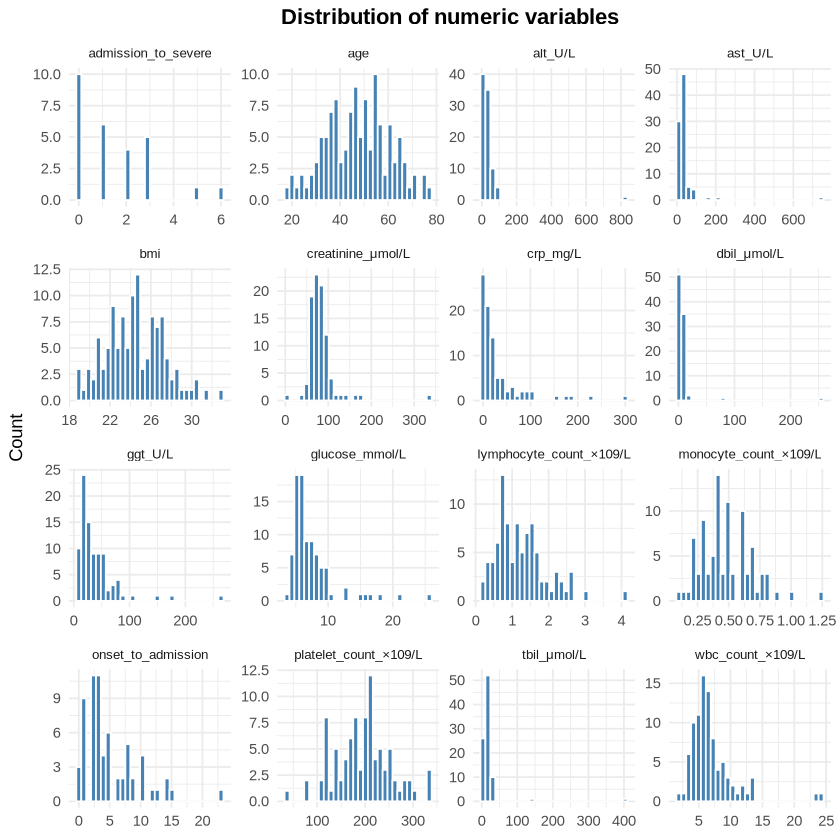

In [18]:

# NUMERIC variables: descriptive statistics

# Despite we have already done descriptive statistics in Exercise 1.1, now we will do it again but for all the numeric variables

numeric_summary <- data_numeric %>%
  summarise(
    across(
      everything(),
      list(
        n = ~sum(!is.na(.)),
        mean = ~mean(., na.rm = TRUE),
        sd = ~sd(., na.rm = TRUE),
        median = ~median(., na.rm = TRUE),
        min = ~min(., na.rm = TRUE),
        max = ~max(., na.rm = TRUE)
      ),
      .names = "{.col}_{.fn}"
    )
  ) %>%
  pivot_longer(
    cols = everything(),
    names_to = c("Variable", "Statistic"),
    names_sep = "_(?=[^_]+$)"
  ) %>%
  pivot_wider(
    names_from = Statistic,
    values_from = value
  )

numeric_summary %>%
  mutate(across(where(is.numeric), ~round(., 2))) %>%
  kable(
    caption = "Descriptive statistics of numeric variables",
    align = "lrrrrrr",
    col.names = c("Variable", "n", "Mean", "SD", "Median", "Min", "Max")
  ) %>%
  kable_styling(
    bootstrap_options = c("striped", "hover", "condensed"),
    full_width = FALSE,
    position = "center"
  )


# Distribution plots
data_numeric_long <- data_numeric %>%
  pivot_longer(
    cols = everything(),
    names_to = "Variable",
    values_to = "Value"
  )
ggplot(
  data_numeric_long %>% filter(!is.na(Value)),
  aes(x = Value)
) +
  geom_histogram(bins = 30, fill = "steelblue", color = "white") +
  facet_wrap(~ Variable, scales = "free") +
  labs(
    title = "Distribution of numeric variables",
    x = NULL,
    y = "Count"
  ) +
  theme_minimal() +
  theme(
    strip.text = element_text(size = 8),
    plot.title = element_text(hjust = 0.5, face = "bold")
  )





# CATEGORICAL variables: frequency tables

# Regarding categorical variables, we have already done the distribution analysis in the previous section (Checking data balancing)
# But we can also show here the frequency tables and the bar plots can be checked at data balancing section
categorical_summary <- lapply(data_categorical, function(x) {
  freq <- table(x)
  perc <- prop.table(freq) * 100
  data.frame(
    Category = names(freq),
    Frequency = as.numeric(freq),
    Percentage = round(as.numeric(perc), 2)
  )
})

categorical_summary



### Bivariate Analysis

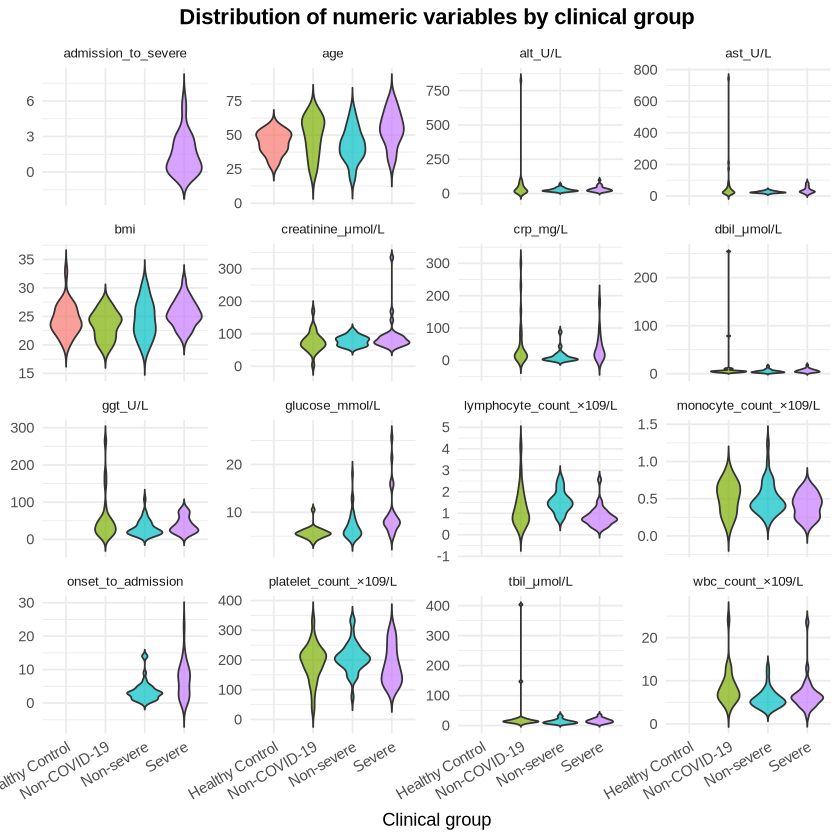

In [19]:
# - Comparisons between key numeric variables and clinical group
data_numeric_long <- data_cleaned %>%
  select(all_of(c(numeric_cols, "group"))) %>%
  pivot_longer(
    cols = all_of(numeric_cols),
    names_to = "Variable",
    values_to = "Value"
  )

ggplot(
  data_numeric_long %>% filter(!is.na(Value)),
  aes(x = group, y = Value, fill = group)
) +
  geom_violin(trim = FALSE, alpha = 0.7) +
  facet_wrap(~ Variable, scales = "free_y") +
  labs(
    title = "Distribution of numeric variables by clinical group",
    x = "Clinical group",
    y = NULL
  ) +
  theme_minimal() +
  theme(
    legend.position = "none",
    strip.text = element_text(size = 8),
    plot.title = element_text(hjust = 0.5, face = "bold"),
    axis.text.x = element_text(angle = 30, hjust = 1)
  )

# Detect Outliers
# This will be the next step but will be done in the Exercise 2.2 section


# Exercise 2

## Exercise 2.1

Reproduce Supplementary Figure 1 using the data without modifying or removing any observations. Use the same variables and groupings as in the original figure.

#### -> Version WITH breaks in the Y-axis


Adjuntando el paquete: ‘ggpubr’


The following objects are masked _by_ ‘.GlobalEnv’:

    mean_sd, median_iqr


ggbreak v0.1.6 Learn more at https://yulab-smu.top/



If you use ggbreak in published research, please cite the following
paper:

S Xu, M Chen, T Feng, L Zhan, L Zhou, G Yu. Use ggbreak to effectively
utilize plotting space to deal with large datasets and outliers.
Frontiers in Genetics. 2021, 12:774846. doi: 10.3389/fgene.2021.774846


aplot v0.2.9 For help: https://github.com/YuLab-SMU/aplot/issues

If you use aplot in published research, please cite the paper:

Shuangbin Xu, Qianwen Wang, Shaodi Wen, Junrui Li, Nan He, Ming Li,
Thomas Hackl, Rui Wang, Dongqiang Zeng, Shixiang Wang, Shensuo Li,
Chunhui Gao, Lang Zhou, Shaoguo Tao, Zijing Xie, Lin Deng, and
Guangchuang Yu. aplot: Simplifying the creation of complex graphs to
visualize associations across diverse data types. The Innovation. 2025,
6(9):100958. doi: 10.1016/j.xinn.2025.100958

Export the citation to BibTex b

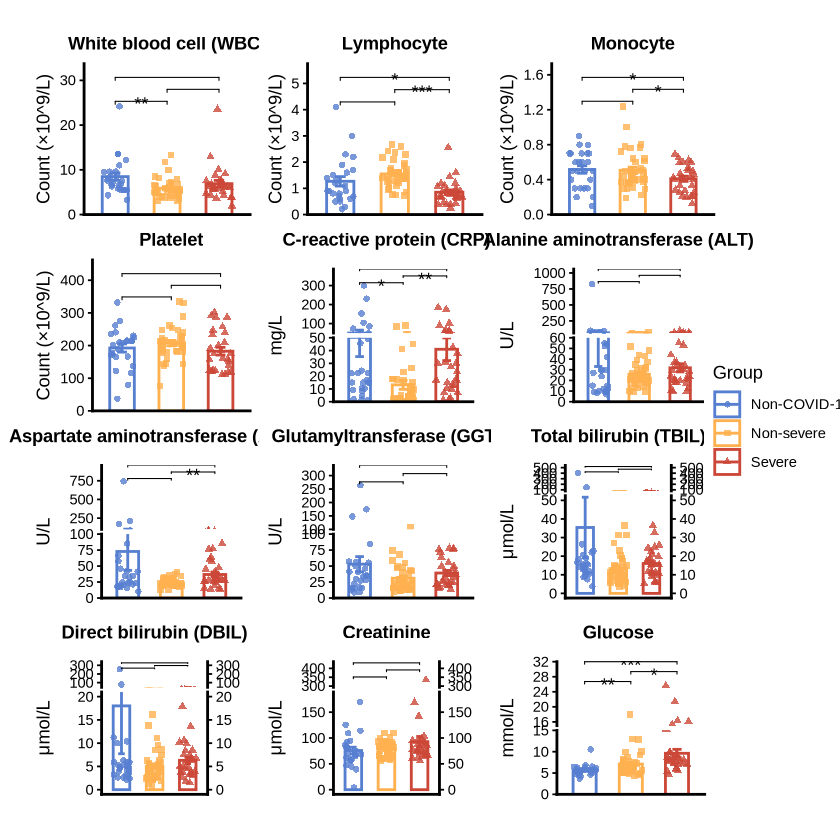

In [20]:

library(ggpubr) 
library(ggplot2)
library(dplyr)
library(ggbreak)
library(ggplotify)

# 1. Prepare the data
data_fig1 <- data_cleaned %>%
  filter(group %in% c("Non-COVID-19", "Non-severe", "Severe")) %>%
  mutate(group = factor(group, levels = c("Non-COVID-19", "Non-severe", "Severe")))

# 2. Define colors and shapes
my_colors <- c("Non-COVID-19" = "#567FD0", "Non-severe" = "#FFB04F", "Severe" = "#CB4838")
# Shapes: 16=Circle, 15=Square, 17=Triangle
my_shapes <- c("Non-COVID-19" = 16, "Non-severe" = 15, "Severe" = 17)

# 3. Define comparisons
my_comparisons <- list(
  c("Non-COVID-19", "Non-severe"),
  c("Non-severe", "Severe"),
  c("Non-COVID-19", "Severe")
)

# 4. Functions to calculate mean and error bars 
# mean ± SD
mean_sd_trunc <- function(x) {
  m <- mean(x, na.rm = TRUE)
  s <- sd(x, na.rm = TRUE)
  
  data.frame(
    y = m,
    ymin = pmax(0, m - s),  # ⬅️ truncado
    ymax = m + s
  )
}
# mean ± SEM
mean_sem <- function(x) {
  m <- mean(x, na.rm = TRUE)
  s <- sd(x, na.rm = TRUE) / sqrt(sum(!is.na(x)))
  data.frame(
    y = m,
    ymin = pmax(0, m - s),
    ymax = m + s
  )
}

# 5. Function to create the bar plot
create_barplot <- function(data, y_var, title, y_label, break_point = NULL, break_scale = NULL, compress_scale = 0.3) {
  
  p <- ggplot(data, aes(x = group, y = .data[[y_var]], color = group)) +
    
    # 5.1. The bars: white fill, colored border
    geom_bar(stat = "summary", fun = "mean", 
             fill = "white",  # The fill is white
             width = 0.5,     # The width of the bar 
             linewidth = 0.8) +    # The width of the border line
    
    # 5.2. Error bars (Mean +/- Standard Error of the Mean)
    stat_summary(fun.data = mean_sem, geom = "errorbar", 
                 width = 0.2, linewidth = 0.8) +
    
    # 5.3. Individual points (Jitter) with different SHAPES
    # Map 'shape' to group as well
    geom_jitter(aes(shape = group), 
                width = 0.25, size = 1.5, alpha = 0.8) +
    
    # 5.4. Significance bars with t-test (Welch's test)
    stat_compare_means(comparisons = my_comparisons, 
                       method = "t.test", 
                       method.args = list(var.equal = FALSE),
                       label = "p.signif",
                       symnum.args = list(cutpoints = c(0, 0.001, 0.01, 0.05, 1), 
                                          symbols = c("***", "**", "*", "ns")),
                       hide.ns = TRUE, # Hide non-significant for clarity
                       color = "black", # Significance bars -> black
                       vjust = 0.8) +
    
    # 5.5. Aesthetics and scales
    scale_color_manual(values = my_colors) +
    scale_shape_manual(values = my_shapes) +
    labs(title = title, y = y_label, x = NULL) +
    theme_classic() +
    theme(
      legend.position = "none",
      plot.title = element_text(hjust = 0.5, size = 11, face = "bold"),
      axis.text.x = element_blank(), # Remove x-axis text
      axis.ticks.x = element_blank(),
      axis.line = element_line(linewidth = 0.8) # Slightly thicker axes
    )
  
  # Adjust y-axis limits
  p <- p + scale_y_continuous(expand = expansion(mult = c(0, 0.1)))

  # Add y-axis break if specified
  if (!is.null(break_point)) {
    if (!is.null(break_scale)) {
      p <- p +
        scale_y_break(
          breaks = c(break_point, break_scale),
          scales = compress_scale
        )
    }else{
      p <- p +
        scale_y_cut(
          breaks = break_point,
          scales = compress_scale
        )
    }
  }

  return(p)
}

# 6. Create the 12 bar plots with the function

p1 <- create_barplot(data_fig1, "wbc_count_×109/L", "White blood cell (WBC)", "Count (×10^9/L)")
p2 <- create_barplot(data_fig1, "lymphocyte_count_×109/L", "Lymphocyte", "Count (×10^9/L)")
p3 <- create_barplot(data_fig1, "monocyte_count_×109/L", "Monocyte", "Count (×10^9/L)")
p4 <- create_barplot(data_fig1, "platelet_count_×109/L", "Platelet", "Count (×10^9/L)")
p5 <- create_barplot(data_fig1, "crp_mg/L", "C-reactive protein (CRP)", "mg/L", break_point = 50, compress_scale = 0.25)
p6 <- create_barplot(data_fig1, "alt_U/L", "Alanine aminotransferase (ALT)", "U/L", break_point = 60, compress_scale = 0.25)
p7 <- create_barplot(data_fig1, "ast_U/L", "Aspartate aminotransferase (AST)", "U/L", break_point = 100, compress_scale = 0.25)
p8 <- create_barplot(data_fig1, "ggt_U/L", "Glutamyltransferase (GGT)", "U/L", break_point = 100, compress_scale = 0.25)
p9 <- create_barplot(data_fig1, "tbil_μmol/L", "Total bilirubin (TBIL)", "μmol/L", break_point = 50, break_scale = 100, compress_scale = 0.25)
p10 <- create_barplot(data_fig1, "dbil_μmol/L", "Direct bilirubin (DBIL)", "μmol/L", break_point = 20, break_scale = 60, compress_scale = 0.25)
p11 <- create_barplot(data_fig1, "creatinine_μmol/L", "Creatinine", "μmol/L", break_point = 180, break_scale = 300, compress_scale = 0.25)
p12 <- create_barplot(data_fig1, "glucose_mmol/L", "Glucose", "mmol/L", break_point = 15, compress_scale = 0.25)

# Libraries
library(aplot)
library(cowplot)
library(patchwork)

# 7. Create a list with our 12 plots (the ones with the break)
lista_plots <- list(
  p1, p2, p3, 
  p4, p5, p6, 
  p7, p8, p9, 
  p10, p11, p12
)

# 8. Extract the shared legend from one of the plots
shared_legend <- get_legend(
  p1 + theme(legend.position = "right") + labs(color = "Group", shape = "Group")
)

# 9. Use plot_list to create the grid
# Align the inner panels (including breaks) 
# so that all axes and drawing areas measure the same.
figure_grid <- plot_list(
  gglist = lista_plots, 
  ncol = 3, 
  nrow = 4
)

figure_s1_final <- wrap_elements(figure_grid) + shared_legend + 
  plot_layout(widths = c(1, 0.1)) # 1 part for the grid, 0.1 for the legend

print(figure_s1_final)

#### -> Version WITHOUT breaks in the Y-axis

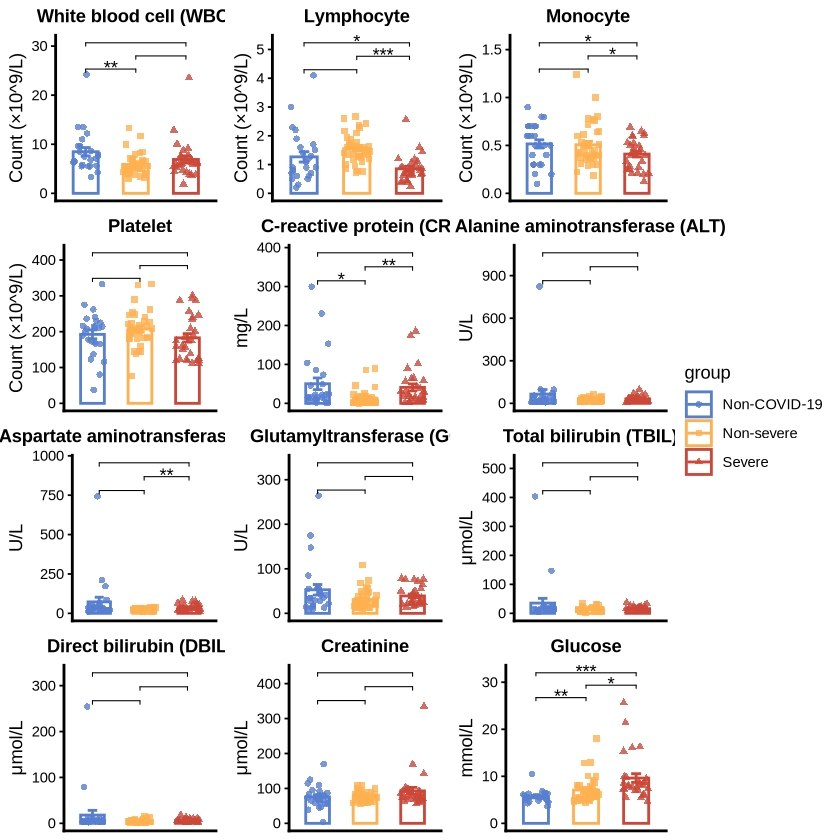

In [ ]:

library(ggpubr) 
library(ggplot2)
library(dplyr)

# 1. Prepare the data
data_fig1 <- data_cleaned %>%
  filter(group %in% c("Non-COVID-19", "Non-severe", "Severe")) %>%
  mutate(group = factor(group, levels = c("Non-COVID-19", "Non-severe", "Severe")))

# 2. Define colors and shapes
my_colors <- c("Non-COVID-19" = "#567FD0", "Non-severe" = "#FFB04F", "Severe" = "#CB4838")
# Shapes: 16=Circle, 15=Square, 17=Triangle
my_shapes <- c("Non-COVID-19" = 16, "Non-severe" = 15, "Severe" = 17)

# 3. Define comparisons
my_comparisons <- list(
  c("Non-COVID-19", "Non-severe"),
  c("Non-severe", "Severe"),
  c("Non-COVID-19", "Severe")
)

# 4. Function to create the bar plot
create_barplot <- function(data, y_var, title, y_label) {
  
  ggplot(data, aes(x = group, y = .data[[y_var]], color = group)) +
    
    # 4.1. The bars: white fill, colored border
    geom_bar(stat = "summary", fun = "mean", 
             fill = "white",  # White fill
             width = 0.5,     # Bar width
             linewidth = 0.8) +    # Border line thickness
    
    # 4.2. Error bars (Mean +/- Standard Error of the Mean)
    stat_summary(fun.data = mean_se, geom = "errorbar", 
                 width = 0.2, linewidth = 0.8) +
    
    # 4.3. Individual points (Jitter) with different SHAPES
    # Map 'shape' to group as well
    geom_jitter(aes(shape = group), 
                width = 0.25, size = 1.5, alpha = 0.8) +
    
    # 4.4. Significance bars with t-test (Welch's test)
    stat_compare_means(comparisons = my_comparisons, 
                       method = "t.test", 
                       method.args = list(var.equal = FALSE),
                       label = "p.signif",
                       symnum.args = list(cutpoints = c(0, 0.001, 0.01, 0.05, 1), 
                                          symbols = c("***", "**", "*", "ns")),
                       hide.ns = TRUE, # Hide non-significant for clarity
                       color = "black", # Significance bars are usually black
                       vjust = 0.5) +
    
    # 4.5. Aesthetics and scales
    scale_color_manual(values = my_colors) +
    scale_shape_manual(values = my_shapes) +
    
    labs(title = title, y = y_label, x = NULL) +
    theme_classic() +
    theme(
      legend.position = "none",
      plot.title = element_text(hjust = 0.5, size = 11, face = "bold"),
      axis.text.x = element_blank(), # Remove x-axis text
      axis.ticks.x = element_blank(),
      axis.line = element_line(linewidth = 0.8) # Slightly thicker axes
    )
}


# 5. Generate the 12 plots with the function

p1 <- create_barplot(data_fig1, "wbc_count_×109/L", "White blood cell (WBC)", "Count (×10^9/L)")
p2 <- create_barplot(data_fig1, "lymphocyte_count_×109/L", "Lymphocyte", "Count (×10^9/L)")
p3 <- create_barplot(data_fig1, "monocyte_count_×109/L", "Monocyte", "Count (×10^9/L)")
p4 <- create_barplot(data_fig1, "platelet_count_×109/L", "Platelet", "Count (×10^9/L)")
p5 <- create_barplot(data_fig1, "crp_mg/L", "C-reactive protein (CRP)", "mg/L")
p6 <- create_barplot(data_fig1, "alt_U/L", "Alanine aminotransferase (ALT)", "U/L")
p7 <- create_barplot(data_fig1, "ast_U/L", "Aspartate aminotransferase (AST)", "U/L")
p8 <- create_barplot(data_fig1, "ggt_U/L", "Glutamyltransferase (GGT)", "U/L")
p9 <- create_barplot(data_fig1, "tbil_μmol/L", "Total bilirubin (TBIL)", "μmol/L")
p10 <- create_barplot(data_fig1, "dbil_μmol/L", "Direct bilirubin (DBIL)", "μmol/L")
p11 <- create_barplot(data_fig1, "creatinine_μmol/L", "Creatinine", "μmol/L")
p12 <- create_barplot(data_fig1, "glucose_mmol/L", "Glucose", "mmol/L")



# 6. Combine and display
figure_s1_bars <- ggarrange(p1, p2, p3, p4, p5, p6, p7, p8, p9, p10, p11, p12,
                            ncol = 3, nrow = 4,
                            common.legend = TRUE, legend = "right") # Legend on the right as reference

print(figure_s1_bars)

ggsave("results/Supplementary_Figure_1_Replicated.png", figure_s1_bars, width = 10, height = 12)

## Exercise 2.2

Identify and handle outliers using an appropriate and well-justified method (e.g. removal, transformation, or robust statistics).

Reproduce Supplementary Figure 1 after outlier handling and discuss how and why the results change.

<table class="table table-striped table-hover table-condensed" style="width: auto !important; margin-left: auto; margin-right: auto;">
<caption>Detailed list of outliers detected using the IQR criterion</caption>
 <thead>
  <tr>
   <th style="text-align:left;"> patient_id </th>
   <th style="text-align:left;"> Variable </th>
   <th style="text-align:right;"> Outlier_value </th>
   <th style="text-align:right;"> Mean_variable </th>
   <th style="text-align:right;"> SD_variable </th>
  </tr>
 </thead>
<tbody>
  <tr>
   <td style="text-align:left;"> HC27 </td>
   <td style="text-align:left;"> bmi </td>
   <td style="text-align:right;"> 32.87 </td>
   <td style="text-align:right;"> 24.50 </td>
   <td style="text-align:right;"> 2.79 </td>
  </tr>
  <tr>
   <td style="text-align:left;"> XG38 </td>
   <td style="text-align:left;"> wbc_count_×109/L </td>
   <td style="text-align:right;"> 12.89 </td>
   <td style="text-align:right;"> 6.92 </td>
   <td style="text-align:right;"> 3.55 </td>
  </t

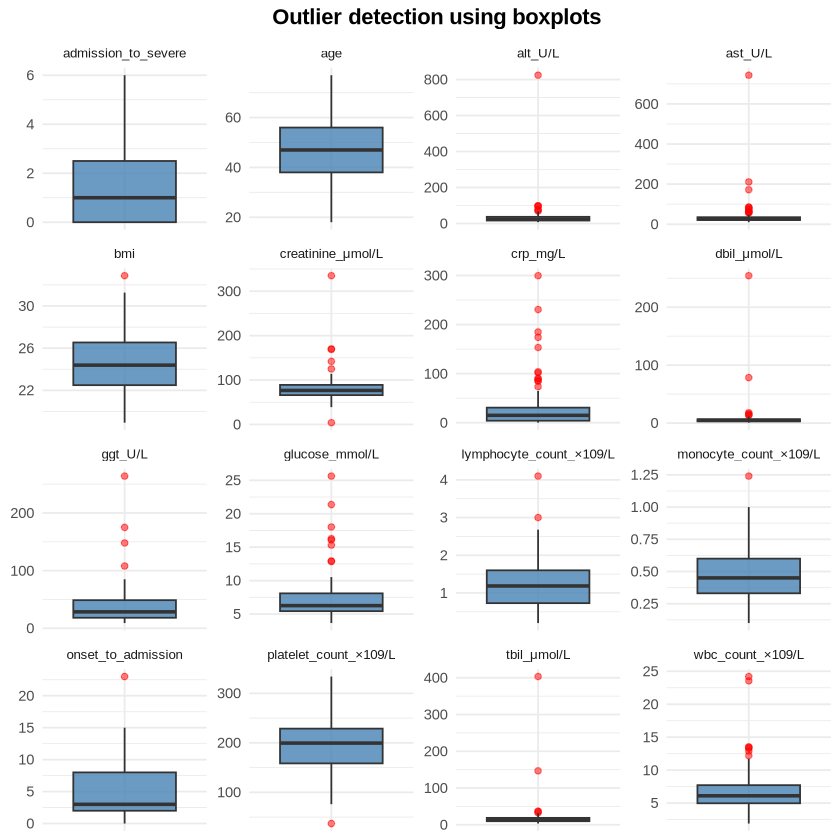

In [22]:
# Outlier detection using boxplots
ggplot(
  data_numeric_long %>% filter(!is.na(Value)),  # Remove NAs for better visualization
  aes(x = "", y = Value)
) +
  geom_boxplot(
    fill = "steelblue",
    alpha = 0.8,    # Transparency of the boxplot fill
    width = 0.75,   # Width of the boxplot   
    outlier.colour = "red", # Color of outliers
    outlier.alpha = 0.5       # Transparency of outliers
  ) +
  facet_wrap(~ Variable, scales = "free_y") +
  labs(
    title = "Outlier detection using boxplots",
    x = NULL,
    y = NULL
  ) +
  theme_minimal() +
  theme(
    strip.text = element_text(size = 8),
    plot.title = element_text(hjust = 0.5, face = "bold"),
    axis.text.x = element_blank(),
    axis.ticks.x = element_blank()
  )

# Outliers summary
library(outliers)
library(purrr)



### Function to detect outliers (IQR based) 
# Outlier detection was performed using IQR-based criteria because Z-score–based methods identified extreme values primarily in approximately normally distributed variables but with this properties we only have age and BMI. In contrast, IQR-based methods were more effective at detecting extreme values in skewed biomarker distributions. Therefore, IQR was considered the most appropriate criterion for summarizing biomarker outliers.

detect_outliers_iqr_long <- function(data, var_name, id_col = "patient_id") {
  
  x <- data[[var_name]]
  ids <- data[[id_col]]
  
  x_clean <- x[!is.na(x)]
  
  bp <- boxplot.stats(x_clean)
  out_vals <- bp$out
  
  if (length(out_vals) == 0) {
    return(tibble())
  }
  
  tibble(
    patient_id = ids[x %in% out_vals],
    Variable = var_name,
    Outlier_value = x[x %in% out_vals]
  ) %>%
    mutate(
      Mean_variable = round(mean(x_clean), 2),
      SD_variable   = round(sd(x_clean), 2)
    ) %>%
    select(
      patient_id,
      Variable,
      Outlier_value,
      Mean_variable,
      SD_variable
    )
}



### Apply to all numeric variables 
outliers_iqr_long_table <- map_dfr(
  numeric_cols,
  ~ detect_outliers_iqr_long(data_cleaned, .x)
)

### Display nicely formatted table 
outliers_iqr_long_table %>%
  mutate(
    Outlier_value = round(Outlier_value, 2)
  ) %>%
  kable(
    caption = "Detailed list of outliers detected using the IQR criterion",
    align = "llrrr"
  ) %>%
  kable_styling(
    bootstrap_options = c("striped", "hover", "condensed"),
    full_width = FALSE,
    position = "center"
  )

# Exercise 3
Create a heatmap of the biomarker data. Include group and gender as annotation variables.

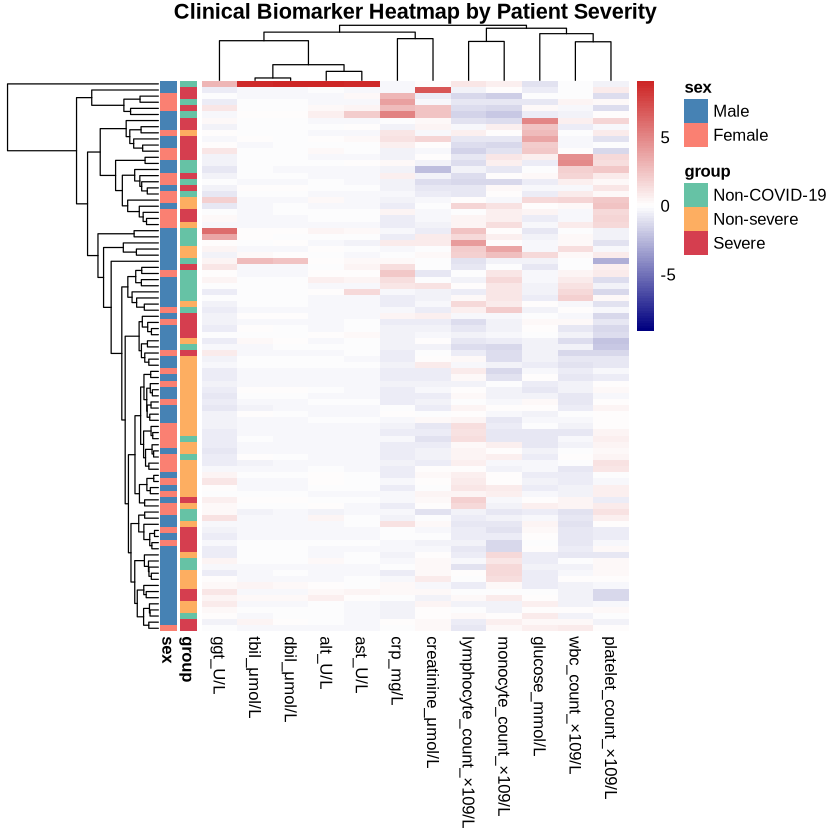

In [23]:
### 1. Install and load necessary library 

if (!require("pheatmap")) install.packages("pheatmap")
library(pheatmap)



### 2. Define biomarkers for analysis 

# We select clinical laboratory variables, excluding time-related metrics
biomarkers_names <- c("wbc_count_×109/L", "lymphocyte_count_×109/L", 
                      "monocyte_count_×109/L", "platelet_count_×109/L",
                      "crp_mg/L", "alt_U/L", "ast_U/L", "ggt_U/L", "tbil_μmol/L", 
                      "dbil_μmol/L", "creatinine_μmol/L", "glucose_mmol/L")



### 3. Prepare the data matrix 

# We filter for patients who have clinical data available
# Note: Healthy controls lack these biomarkers (NAs) so, will be discarded
data_heatmap <- data_cleaned %>%
  drop_na(all_of(biomarkers_names))


# Normalization of the data (Z-score)
# Convert the selected columns into a numeric matrix for pheatmap
mat_raw <- data_heatmap %>%
  select(all_of(biomarkers_names)) %>%
  as.matrix()

mat_normalized <- scale(mat_raw)    # Standardization: (x - mean) / sd


# Convert to data frame to check the normalized values
df_normalized <- as.data.frame(mat_normalized)
df_normalized$patient_id <- data_heatmap$patient_id


# Assign patient IDs as row names to maintain traceability
rownames(mat_normalized) <- data_heatmap$patient_id


# Force symmetric color scale so that 0 is exactly white
max_abs <- max(abs(mat_normalized), na.rm = TRUE)


# Define breaks centered at 0
breaks <- seq(-max_abs, max_abs, length.out = 101)




### 4. Create Metadata Annotations (Group and Sex) 
# This dataframe defines the color bars shown at the top/side of the heatmap
anno_df <- data_heatmap %>%
  select(group, sex) %>%
  as.data.frame()

# Row names must match the matrix row names
rownames(anno_df) <- data_heatmap$patient_id

# Define specific color palettes for the clinical groups and sex
anno_colors <- list(
  group = c("Non-COVID-19" = "#66c2a5", "Non-severe" = "#fdae61", "Severe" = "#d53e4f"),
  sex = c("Male" = "steelblue", "Female" = "salmon")
)



### 5. Generate the Heatmap 
pheatmap(
  mat_normalized,
  cluster_rows = TRUE,         # Cluster patients with similar clinical profiles
  cluster_cols = TRUE,         # Cluster biomarkers that behave similarly
  scale = "none",              # We already normalized manually
  annotation_row = anno_df,    # Add group and sex sidebars
  annotation_colors = anno_colors,
  show_rownames = FALSE,       # Hide individual IDs for better readability
  
  treeheight_row = 90,        # Increases the width of the left dendrogram
  treeheight_col = 30,        # Height of the top dendrogram
  fontsize_col = 10,
  main = "Clinical Biomarker Heatmap by Patient Severity",
  
  # Color palette
  color = colorRampPalette(c("navy", "white", "firebrick3"))(100),
  breaks = breaks, 
  border_color = NA
)

In [28]:

### 1. Install and load necessary library
if (!require("pheatmap")) install.packages("pheatmap")
library(pheatmap)

make_biomarker_heatmap <- function(data, log_transform = TRUE, title_suffix = "") {
  


  ### 2. Define biomarkers for analysis
  # We select clinical laboratory variables, excluding time-related metrics
  biomarkers_names <- c("wbc_count_×109/L", "lymphocyte_count_×109/L", 
                      "monocyte_count_×109/L", "platelet_count_×109/L",
                      "crp_mg/L", "alt_U/L", "ast_U/L", "ggt_U/L", "tbil_μmol/L", 
                      "dbil_μmol/L", "creatinine_μmol/L", "glucose_mmol/L")
  


  ### 3. Prepare the data matrix
  # We filter for patients who have clinical data available
  # Note: Healthy controls lack these biomarkers (NAs) so, will be discarded
  data_heatmap <- data %>%
    drop_na(all_of(biomarkers_names))
  
  # Normalization of the data (Z-score)
  # Convert the selected columns into a numeric matrix for pheatmap
  mat_raw <- data_heatmap %>%
    select(all_of(biomarkers_names)) %>%
    as.matrix()
  
  if (log_transform){
    mat_raw <- log1p(mat_raw)
    norm_label <- "log1p + z-score"
  }else{
    norm_label <- "z-score"
  }
  
  mat_normalized <- scale(mat_raw)    # Standardization: (x - mean) / sd

  # Assign patient IDs as row names to maintain traceability
  rownames(mat_normalized) <- data_heatmap$patient_id
  
  # Force symmetric color scale so that 0 is exactly white
  max_abs <- max(abs(mat_normalized), na.rm = TRUE)

  # Define breaks centered at 0
  breaks <- seq(-max_abs, max_abs, length.out = 101)
  



  ### 4. Create Metadata Annotations (Group and Sex)
  # This dataframe defines the color bars shown at the top/side of the heatmap
  anno_df <- data_heatmap %>%
    select(group, sex) %>%
    as.data.frame()
  
  # Row names must match the matrix row names
  rownames(anno_df) <- data_heatmap$patient_id
  
  # Define specific color palettes for the clinical groups and sex
  anno_colors <- list(
    group = c("Non-COVID-19" = "#66c2a5", "Non-severe" = "#fdae61", "Severe" = "#d53e4f"),
    sex = c("Male" = "steelblue", "Female" = "salmon")
  )
  


  ### 5. Generate the Heatmap 
  pheatmap(
    mat_normalized,
    cluster_rows = TRUE,         # Cluster patients with similar clinical profiles
    cluster_cols = TRUE,         # Cluster biomarkers that behave similarly
    scale = "none",              # We already normalized manually
    annotation_row = anno_df,    # Add group and sex sidebars
    annotation_colors = anno_colors,
    show_rownames = FALSE,       # Hide individual IDs for better readability
    
    treeheight_row = 90,        # Increases the width of the left dendrogram
    treeheight_col = 30,        # Height of the top dendrogram
    fontsize_col = 10,
    main = paste(
      "Clinical Biomarker Heatmap by Patient Severity",
      title_suffix,
      paste0("(", norm_label, ")")
    ),
    
    # Color palette
    color = colorRampPalette(c("navy", "white", "firebrick3"))(100),
    breaks = breaks,
    border_color = NA
  )
}



make_biomarker_heatmap_woPrevScale <- function(data, title_suffix = "") {
  
  ### 2. Define biomarkers for analysis 
  # We select clinical laboratory variables, excluding time-related metrics
  biomarkers_names <- c("wbc_count_×109/L", "lymphocyte_count_×109/L", 
                      "monocyte_count_×109/L", "platelet_count_×109/L",
                      "crp_mg/L", "alt_U/L", "ast_U/L", "ggt_U/L", "tbil_μmol/L", 
                      "dbil_μmol/L", "creatinine_μmol/L", "glucose_mmol/L")
  


  ### 3. Prepare the data matrix 
  # We filter for patients who have clinical data available
  # Note: Healthy controls lack these biomarkers (NAs) so, will be discarded
  data_heatmap <- data %>%
    drop_na(all_of(biomarkers_names))
  
  # Normalization of the data (Z-score)
  # Convert the selected columns into a numeric matrix for pheatmap
  mat_raw <- data_heatmap %>%
    select(all_of(biomarkers_names)) %>%
    as.matrix()

  # Assign patient IDs as row names to maintain traceability
  rownames(mat_raw) <- data_heatmap$patient_id
  


  ### 4. Create Metadata Annotations (Group and Sex) 
  # This dataframe defines the color bars shown at the top/side of the heatmap
  anno_df <- data_heatmap %>%
    select(group, sex) %>%
    as.data.frame()
  
  # Row names must match the matrix row names
  rownames(anno_df) <- data_heatmap$patient_id
  
  # Define specific color palettes for the clinical groups and sex
  anno_colors <- list(
    group = c("Non-COVID-19" = "#66c2a5", "Non-severe" = "#fdae61", "Severe" = "#d53e4f"),
    sex = c("Male" = "steelblue", "Female" = "salmon")
  )
  


  ### 5. Generate the Heatmap 
  pheatmap(
    mat_raw,
    cluster_rows = TRUE,         # Cluster patients with similar clinical profiles
    cluster_cols = TRUE,         # Cluster biomarkers that behave similarly
    scale = "column",              # We already normalized manually
    annotation_row = anno_df,    # Add group and sex sidebars
    annotation_colors = anno_colors,
    show_rownames = FALSE,       # Hide individual IDs for better readability
    
    treeheight_row = 90,        # Increases the width of the left dendrogram
    treeheight_col = 30,        # Height of the top dendrogram
    fontsize_col = 10,
    main = "Clinical Biomarker Heatmap by Patient Severity",
    
    # Color palette
    color = colorRampPalette(c("navy", "white", "firebrick3"))(100),
    border_color = NA
  )
}


One non-COVID patient (JBDZ2) presented extremely elevated liver enzymes, which could potentially influence clustering after z-score normalization. To assess the robustness of the results, a sensitivity analysis was performed by repeating the heatmap after excluding this patient. The overall clustering patterns were [preserved / clarified], indicating that the main findings are [robust / partially influenced] by this extreme observation.

#### Now, different heatmaps; with/without patient JBDZ2 and with/without logaritmic transformation (for an optimal visualisation of the results)

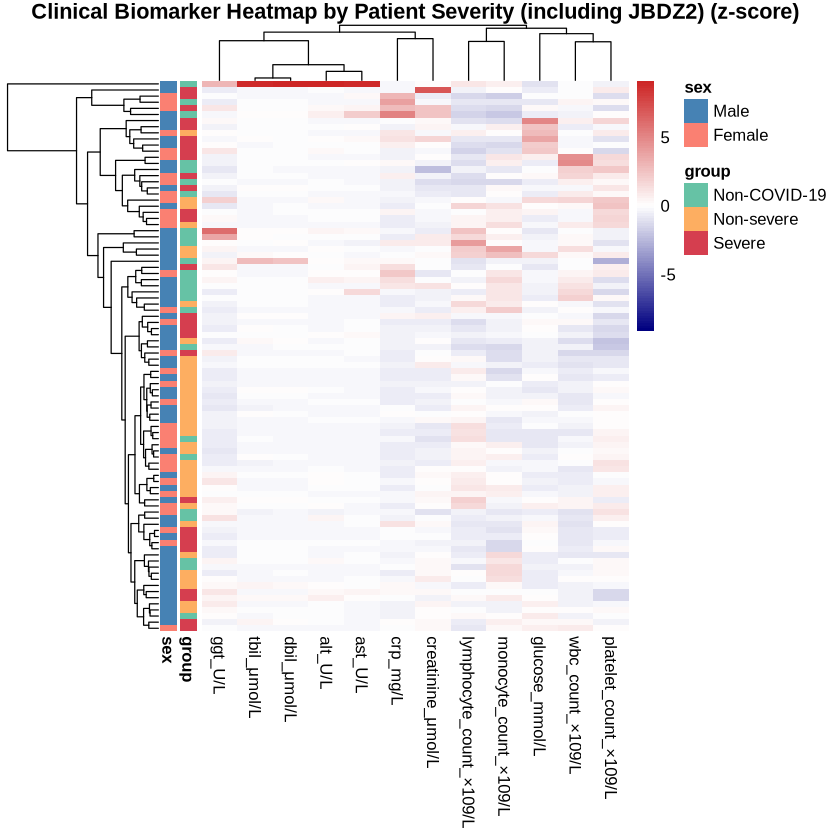

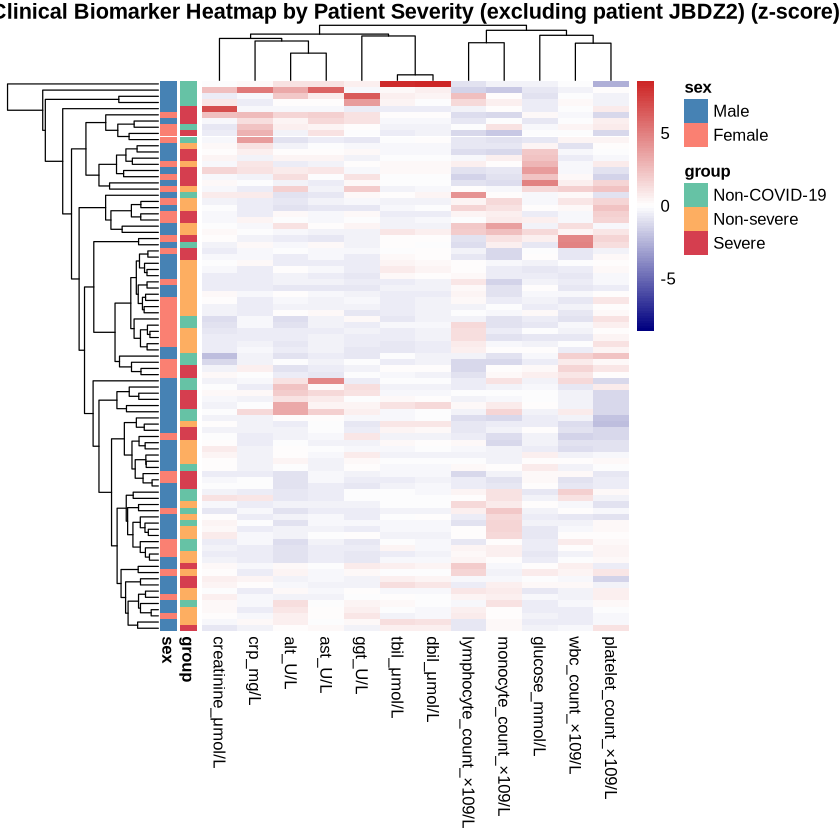

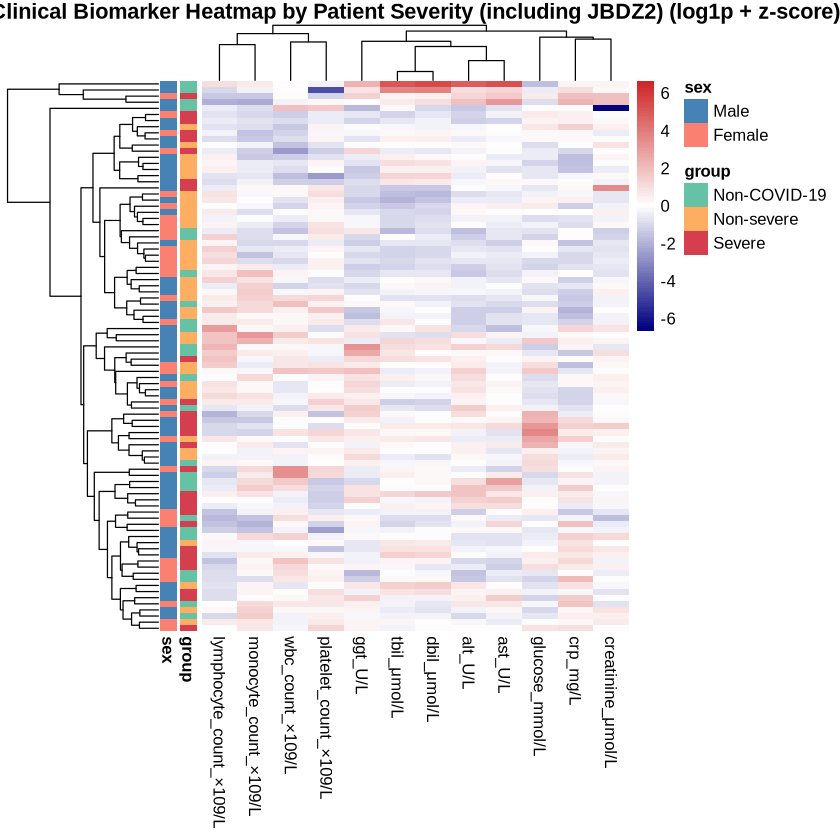

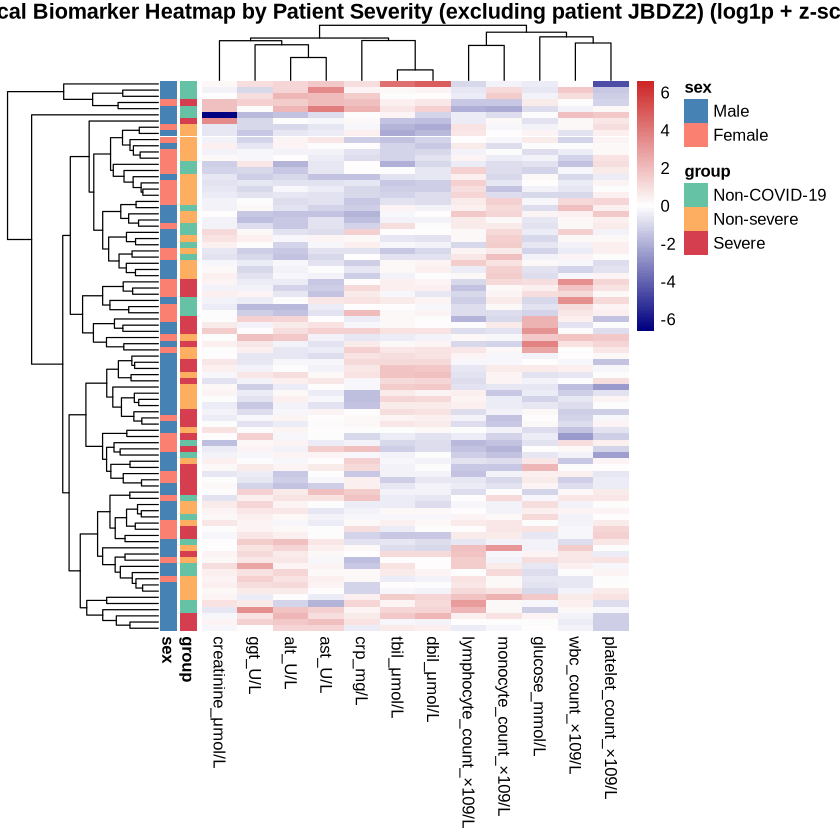

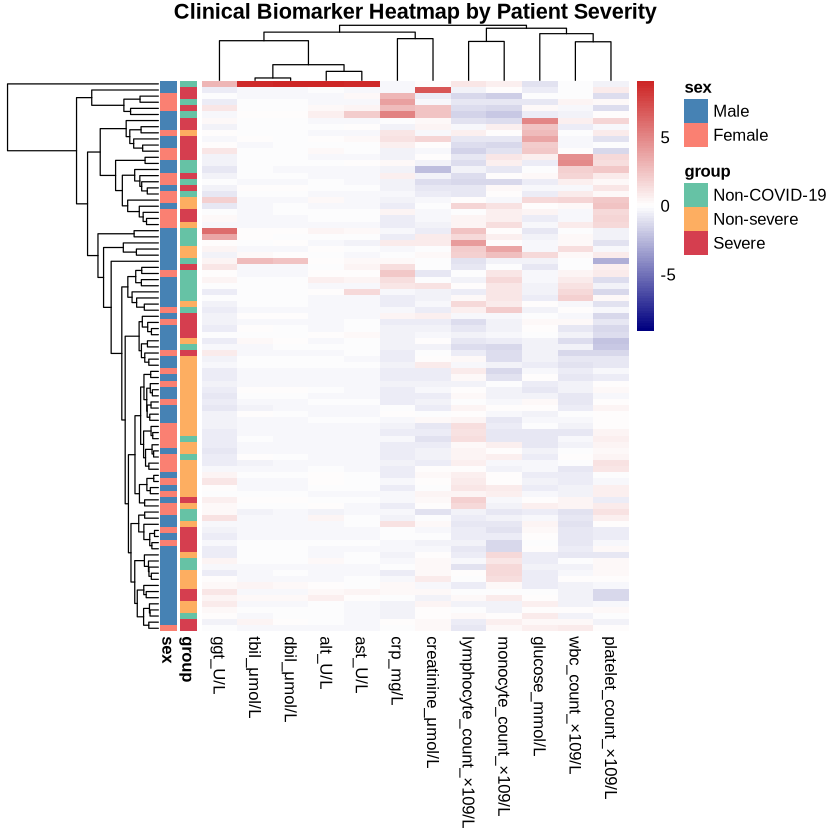

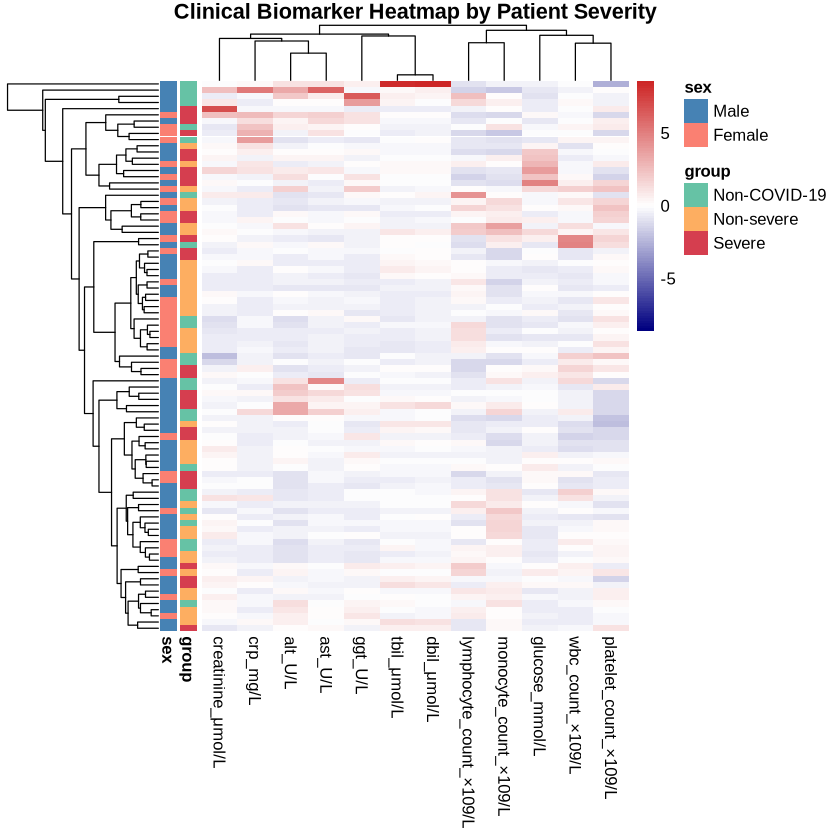

In [29]:
data_cleaned_no_JBDZ2 <- data_cleaned %>%
  filter(patient_id != "JBDZ2")

make_biomarker_heatmap(data_cleaned, FALSE, "(including JBDZ2)")

make_biomarker_heatmap(data_cleaned_no_JBDZ2, FALSE, "(excluding patient JBDZ2)")

make_biomarker_heatmap(data_cleaned, TRUE, "(including JBDZ2)")

make_biomarker_heatmap(data_cleaned_no_JBDZ2, TRUE, "(excluding patient JBDZ2)")

make_biomarker_heatmap_woPrevScale(data_cleaned, "(including JBDZ2)")

make_biomarker_heatmap_woPrevScale(data_cleaned_no_JBDZ2, "(excluding patient JBDZ2)")

### As a conclusion,
One non-COVID patient (JBDZ2) presented extremely elevated liver enzymes, which could potentially influence clustering after z-score normalization.
To assess the robustness of the results, a sensitivity analysis was performed by repeating the heatmap after excluding this patient. The overall clustering patterns were [preserved / clarified], indicating that the main findings are [robust / partially influenced] by this extreme observation.

## SESSION INFO

In [ ]:
import session_info
session_info.show()